In [138]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langchain_mistralai import ChatMistralAI
from typing import TypedDict, Literal
from dotenv import load_dotenv

In [139]:
load_dotenv()


True

In [140]:
llm = ChatMistralAI()

In [141]:
class SentimentSchema(BaseModel):
    sentiment : Literal["positive", "negative"] = Field(description="sentiment of the review")


class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The Emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

    
    

In [142]:
structured_llm = llm.with_structured_output(SentimentSchema)


In [143]:
prompt = "What is the sentiment of the following review - The software is not so good, UI is good and their databases have backups."

In [144]:
structured_llm.invoke(prompt).sentiment
diagnosis_strustured_llm = llm.with_structured_output(DiagnosisSchema)


In [145]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str
    

In [146]:
def find_sentiment(state:ReviewState) -> ReviewState:
    prompt = f"for the following review, find out the sentiment \n {state["review"]}"
    sentiment = structured_llm.invoke(prompt).sentiment

    return {"sentiment":sentiment}


def check_sentiment(state:ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    else :
        return "run_diagnosis"


def positive_response(state: ReviewState) -> ReviewState:

    prompt = f""" Write a kind response to this review - 
                  \n {state['review']} \n
                  ask user kindly to leave a feedback on our website.
              """

    response = llm.invoke(prompt).content

    return {"response": response}


def run_diagnosis(state: ReviewState) -> ReviewState:

    prompt = f""" Diagnos this negative review - 
                  \n {state["review"]} \n 
                  Return issue_type, tone and urgency.
              """ 
    
    response = diagnosis_strustured_llm.invoke(prompt)

    return {"diagnosis": response.model_dump()}


def negative_response(state: ReviewState) -> ReviewState:
    diagnosis = state["diagnosis"]
    prompt = f""" You are a support assistant. 
                  The user had a {diagnosis["issue_type"]} issue sounded {diagnosis["tone"]} and marked urgency as {diagnosis["urgency"]}.
                  Write and empathetic, helpful resolution.
              """
    response = llm.invoke(prompt).content

    return {"response":response}

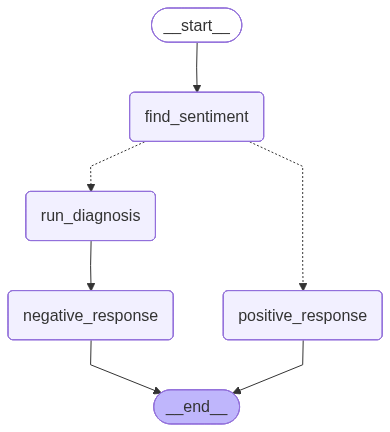

In [147]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("positive_response", positive_response)
graph.add_node("negative_response", negative_response)



graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)
graph.add_edge("run_diagnosis", "negative_response")

graph.add_edge("positive_response", END)
graph.add_edge("negative_response", END)



workflow = graph.compile()

workflow

In [148]:
initial_state = {"review":"The UI is just not good, overall performance very bad"}

output_state = workflow.invoke(initial_state)

print(output_state)

{'review': 'The UI is just not good, overall performance very bad', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'UX', 'tone': 'frustrated', 'urgency': 'high'}, 'response': "Here’s a thoughtful, empathetic response to address the user’s UX issue with urgency and care:\n\n---\n\n**Subject:** I’m here to help—let’s resolve this together\n\nHi [User's Name],\n\nI’m really sorry to hear you’re experiencing this issue—that’s the last thing anyone wants when using [product/service]. I know how frustrating it can be when something isn’t working as expected, especially when it disrupts your workflow.\n\nTo get this fixed quickly, could you share a few more details so I can assist you better?\n- What exactly are you trying to do when the issue occurs? (A screenshot or short description would help!)\n- Have you noticed any error messages or unusual behavior?\n\nI’ll do everything I can to resolve this for you right away. If you’d prefer, I can also [offer alternative support options, e.g